# `SXI_Dynamic_Time_Integration_method` — examples and verification results

Demonstrates the module's public API (`run_DTI_pipeline` and the individual
Test 1/2/3 functions) on real SMILE SXI simulated data, and documents the
verification work used to validate it against the original DIT analysis:

- a sweep of integration-time detections across PCA component counts
- confusion-matrix and precision/recall/accuracy against ground truth
- example DIT reconstructions vs. ground truth
- a per-image breakdown of *why* each image was accepted or rejected (cusp /
  magnetopause / neither)
- standalone accuracy of Test 2 (cusp identification) and Test 3
  (magnetopause-in-FOV), including a documented experiment on making Test 3's
  curve fit more robust -- concluding it should **not** be changed, since
  forcing convergence on ambiguous images trades honest failures for
  confidently wrong answers

Two intermediate results are cached to disk on first run (`dico_DIT_ncompo_module.pkl`,
`dff_ground_truth_stats.pkl`) since they take a while to compute; delete
either file to force a recompute. Requires the SMILE_challenge simulated
dataset and its noise-free `cxmap` ground truth at the relative paths set up
below -- adjust if your data lives elsewhere.

In [1]:
import SXI_Dynamic_Time_Integration_method as dti

from glob import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from astropy.io import fits
from scipy.optimize import curve_fit, OptimizeWarning
from skimage.feature import peak_local_max
from multiprocess import Pool

warnings.filterwarnings("ignore", category=OptimizeWarning)

## Paths and constants

In [2]:
path_directories = np.array(sorted(glob('../../../SMILE_challenge/gac_sims/*')))
path_directories_no_noise = np.array(sorted(glob('../cxmap/*')))
N_IMAGES = len(path_directories)

times = [
    p[-27:-23] + '-' + p[-23:-21] + '-' + p[-21:-19] + ' ' + p[-18:-16] + ':' + p[-16:-14]
    for p in path_directories
]

P, T = np.linspace(-7.75, 7.75, 64), np.linspace(-54 * 0.25, 54 * 0.25, 108)
PP, TT = np.meshgrid(P, T)

## Quick usage example

`run_DTI_pipeline` is the module's single public entry point: given an image
index, it runs Test 1 (minimum integration time for the magnetosheath to
appear), Test 2 (reject cusps) and Test 3 (magnetopause in field of view), and
returns whether the event is a valid DTI detection, the integration time it
used, and the reconstructed image.

image 1850: DTI status=True, integration time=1 frames


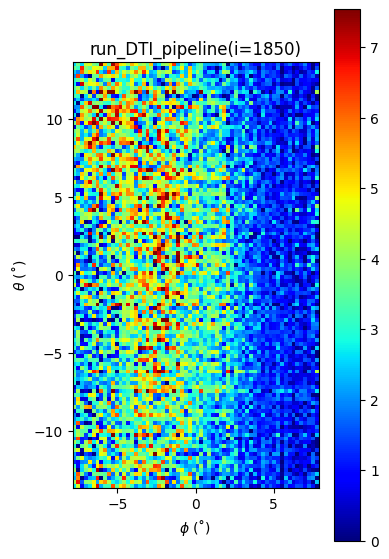

In [3]:
example_index = 1850
status, ni, image = dti.run_DTI_pipeline(example_index, path_directories, n_components=10)
print(f'image {example_index}: DTI status={status}, integration time={ni} frames')

plt.figure(figsize=(4, 6))
plt.pcolormesh(PP, TT, image, cmap='jet', norm=Normalize(0, np.quantile(image, 0.99)))
plt.gca().set_aspect('equal')
plt.xlabel(r'$\phi$ (˚)')
plt.ylabel(r'$\theta$ (˚)')
plt.title(f'run_DTI_pipeline(i={example_index})')
plt.colorbar()
plt.tight_layout()

## DIT sweep, using the module's `run_DTI_pipeline` directly

For each candidate number of SVD components, find the minimum integration
time for every image via `run_DTI_pipeline` (which internally runs Test 1,
Test 2, and Test 3 with a fixed 10-frame window for the magnetopause check).
The result for component count `k` is a 1-minute-resampled timeline
(`dico[k]`) with one row per image, `it` = chosen integration time or `NaN` if
no valid detection was found. This is the expensive step, so it's cached to
`dico_DIT_ncompo_module.pkl`.

In [4]:
def compute_dit_timeline_module(n_components, i_min=5, i_max=2470, n_workers=10):
    i_values = np.arange(i_min, i_max)

    def _run(i):
        status, ni, _ = dti.run_DTI_pipeline(
            i, path_directories, n_components,
            max_ni=10, ni_verif=3, ni_cusp=30, ni_mp=10,
        )
        return ni if status else np.nan

    with Pool(n_workers) as pool:
        itimes = np.array(pool.map(_run, i_values))

    i_msh, i_time = i_values[~np.isnan(itimes)], itimes[~np.isnan(itimes)]

    df = pd.DataFrame(
        index=pd.to_datetime(times)[np.array([0] + list(i_msh) + [N_IMAGES - 1])],
        data={'it': np.array([np.nan] + list(i_time) + [np.nan])},
    ).resample('1min').mean()
    return df

In [5]:
DICO_CACHE = 'dico_DIT_ncompo_module.pkl'
N_COMPONENTS_RANGE = range(2, 26)

try:
    dico = pd.read_pickle(DICO_CACHE)
    assert set(N_COMPONENTS_RANGE) <= set(dico.keys())
except (FileNotFoundError, AssertionError):
    dico = {}
    for n_components in N_COMPONENTS_RANGE:
        print(n_components)
        dico[n_components] = compute_dit_timeline_module(n_components)
    pd.to_pickle(dico, DICO_CACHE)

{k: int(dico[k].it.notna().sum()) for k in dico}

{2: 1699,
 3: 1632,
 4: 1538,
 5: 1419,
 6: 1350,
 7: 1294,
 8: 1238,
 9: 1192,
 10: 1146,
 11: 1103,
 12: 1055,
 13: 1028,
 14: 1004,
 15: 976,
 16: 957,
 17: 945,
 18: 929,
 19: 923,
 20: 913,
 21: 904,
 22: 891,
 23: 881,
 24: 871,
 25: 865}

## Ground-truth validity labels

Two ground-truth signals, built from the noise-free `cxmap` simulation:

- `valid_msh`: for every single frame (no stacking), is the msh visible and
  free of cusp contamination?
- `dff`: windowed (10-frame) signal statistics -- how strong the msh
  signature is relative to the DIT-stack's residual noise
  (`pic_im / std_phi_noise`), used below to decide whether an event was
  strong enough to be worth detecting at all.

In [6]:
def is_subsolar_mp_in_image(image):
    av_phi = np.mean(image, axis=0)
    peaks = peak_local_max(av_phi)
    if len(peaks) == 0:
        return False
    return bool(av_phi[peaks[0]] >= av_phi.max())


def compute_ground_truth_labels():
    """Ground-truth (cusp, subsolar-mp-present) labels from the noise-free
    cxmap simulation, evaluated frame-by-frame."""
    mp = np.array([
        is_subsolar_mp_in_image(
            fits.open(sorted(glob(path_directories_no_noise[i] + '/*'))[0])[0].data
            / dti.load_smile_images(path_directories[i])[-1]
        )
        for i in range(N_IMAGES)
    ])
    cusps = np.array([
        dti.test2_is_cusp(
            fits.open(sorted(glob(path_directories_no_noise[i] + '/*'))[0])[0].data
            / dti.load_smile_images(path_directories[i])[-1]
        )
        for i in range(N_IMAGES)
    ])
    return cusps, mp


gt_cusp, gt_mp_raw = compute_ground_truth_labels()
valid_msh = (~gt_cusp) & gt_mp_raw
int(valid_msh.sum())

1382

In [7]:
def reconstruct_ground_truth(i, ni):
    """Ground-truth (image, background) for the ni-frame window centred on i,
    summed over the window and normalised by the mean exposure map -- matches
    the sum(frames)/mean(exposure) convention used throughout this analysis."""
    lo, hi = int(i - ni / 2), int(i + ni / 2)
    vin = np.mean([dti.load_smile_images(path_directories[j])[-1] for j in range(lo, hi)], axis=0)
    gt_sum = np.sum([fits.open(sorted(glob(path_directories_no_noise[j] + '/*'))[0])[0].data for j in range(lo, hi)], axis=0)
    bkg_sum = np.sum([dti.load_smile_images(path_directories[j])[0] for j in range(lo, hi)], axis=0)
    return gt_sum / vin, bkg_sum / vin


def compute_ground_truth_stats(i_max=2495, window=10):
    rows = []
    for i in range(i_max):
        image, bkg = reconstruct_ground_truth(i, window)
        noisy = dti.stack_images(i, window, path_directories)

        av_phi_im = dti.average_along_phi_axis(image)
        av_phi_noisy = dti.average_along_phi_axis(noisy)
        av_phi_residual = dti.average_along_phi_axis(noisy - bkg - image)

        rows.append(dict(
            mean_bkg=bkg.mean(), std_bkg=bkg.std(),
            noise=(noisy - bkg - image).std(), all_noise=noisy.std(),
            std_im=image.std(), mean_im=image.mean(), max_im=image.max(),
            pic_im=av_phi_im.max() - av_phi_im.min(),
            std_phi_noise=av_phi_residual.std(),
            std_phi_all_noise=av_phi_noisy.std(),
        ))

    idx = pd.to_datetime(times[:i_max])
    return pd.DataFrame(rows, index=idx).reindex(pd.to_datetime(times)).resample('1min').mean()


DFF_CACHE = 'dff_ground_truth_stats.pkl'

try:
    dff = pd.read_pickle(DFF_CACHE)
except FileNotFoundError:
    dff = compute_ground_truth_stats()
    dff.to_pickle(DFF_CACHE)

dff[['pic_im', 'std_phi_noise']].describe()

,pic_im,std_phi_noise
count,2495.000000,2495.000000
mean,4.587631,0.817160
std,8.600428,0.853766
min,0.066028,0.266131
25%,0.468483,0.441246
50%,1.277570,0.587811
75%,4.101771,0.777474
max,59.484337,4.974642


## Classify DIT decisions against ground truth (`n_components = 10`)

In [8]:
def classify(it_column, valid, threshold_ratio=1.5, ratio=None):
    if ratio is None:
        ratio = (dff.pic_im / dff.std_phi_noise).values
    valid = valid & (ratio >= threshold_ratio)
    predicted = ~it_column.isna().values
    tp = np.flatnonzero(valid & predicted)
    tn = np.flatnonzero(~valid & ~predicted)
    fp = np.flatnonzero(~valid & predicted)
    fn = np.flatnonzero(valid & ~predicted)
    return tp, tn, fp, fn


K_FIDUCIAL = 10
df = dico[K_FIDUCIAL]
tp, tn, fp, fn = classify(df.it, valid_msh)
len(tp), len(tn), len(fp), len(fn)

(1019, 1255, 127, 99)

### Figure — per-image classification breakdown (`timeserie_categories_module.pdf`)

Same idea as the timeline above, but broken out by *why* an image was accepted
or rejected instead of collapsing everything to a single valid/invalid call.
`run_DTI_pipeline`'s three tests place every image in exactly one of three
predicted categories: `cusp` (Test 1 found structure, Test 2 flagged it as a
cusp), `mp` (a full magnetopause detection: Test 1 and Test 3 both passed), or
`none` (no structure found, or structure found but rejected by Test 3). Ground
truth (from the noise-free `cxmap` simulation) assigns the same three
categories independently. A predicted cusp is marked `x`, a predicted
magnetopause detection is marked with a dot, colored green if it matches
ground truth and red if it doesn't; a `none` prediction gets no marker, but
still counts toward the green/red background, since a `none` that should have
been a `cusp` or `mp` is itself a miss.

In [9]:
# Test 2 runs on a fixed 30-frame window (15 images on each side), so it can
# only be evaluated where there are at least 15 neighbouring images on both
# sides -- otherwise stack_images would silently wrap to indices at the other
# end of path_directories. This trims 15 images off each end, on top of the
# margin Test 1 already needs.
CUSP_WINDOW_MARGIN = 15
I_MIN, I_MAX = CUSP_WINDOW_MARGIN, N_IMAGES - CUSP_WINDOW_MARGIN


def classify_dti_outcome(i, gt_cusp_i, n_components=K_FIDUCIAL, max_ni=10, ni_verif=3, ni_cusp=30, ni_mp=10):
    """Predicted category for image i: 'cusp', 'mp', or 'none'. Unlike
    run_DTI_pipeline, Test 2 (cusp) is evaluated whenever ground truth says the
    image is actually a cusp OR Test 1 finds a valid msh structure -- so a true
    cusp can still be flagged even without an msh detection, without wasting
    compute (and risking spurious flags) on frames that are neither. Test 3
    (magnetopause) still only applies once Test 1 has succeeded. Cusp markers
    are always placed at y=max_ni on the figure, since Test 2 runs on a fixed
    ni_cusp-frame window unrelated to the msh integration time."""
    status_structure, ni = dti.find_min_integration_time(
        i, path_directories, n_components=n_components, max_ni=max_ni, min_ni=1, ni_verif=ni_verif
    )

    if gt_cusp_i or status_structure:
        cusp_image = dti.remove_noise_with_tsvd(dti.stack_images(i, ni_cusp, path_directories), n_components=n_components)
        if dti.test2_is_cusp(cusp_image):
            return 'cusp', max_ni

    if not status_structure:
        return 'none', ni

    mp_image = dti.remove_noise_with_tsvd(dti.stack_images(i, ni_mp, path_directories), n_components=n_components)
    if dti.test3_is_mp_in_fov(mp_image):
        return 'mp', ni

    return 'none', ni


def classify_dti_outcomes(n_components=K_FIDUCIAL, i_min=I_MIN, i_max=I_MAX, n_workers=10):
    i_values = np.arange(i_min, i_max)

    def _classify(i):
        return classify_dti_outcome(i, bool(gt_cusp[i]), n_components=n_components)

    with Pool(n_workers) as pool:
        results = pool.map(_classify, i_values)

    categories = np.full(N_IMAGES, 'none', dtype=object)
    ni_values = np.full(N_IMAGES, np.nan)
    for i, (category, ni) in zip(i_values, results):
        categories[i] = category
        ni_values[i] = ni
    return categories, ni_values


predicted_category, predicted_ni = classify_dti_outcomes()
{c: int((predicted_category == c).sum()) for c in ('cusp', 'mp', 'none')}

{'cusp': 458, 'mp': 1146, 'none': 896}

In [10]:
ratio = (dff.pic_im / dff.std_phi_noise).values
gt_valid = valid_msh & (ratio >= 1.5)  # same 'strong enough to matter' criterion used above

gt_category = np.full(N_IMAGES, 'none', dtype=object)
gt_category[gt_cusp] = 'cusp'
gt_category[gt_valid] = 'mp'  # mutually exclusive with gt_cusp by construction

{c: int((gt_category == c).sum()) for c in ('cusp', 'mp', 'none')}

{'cusp': 533, 'mp': 1118, 'none': 849}

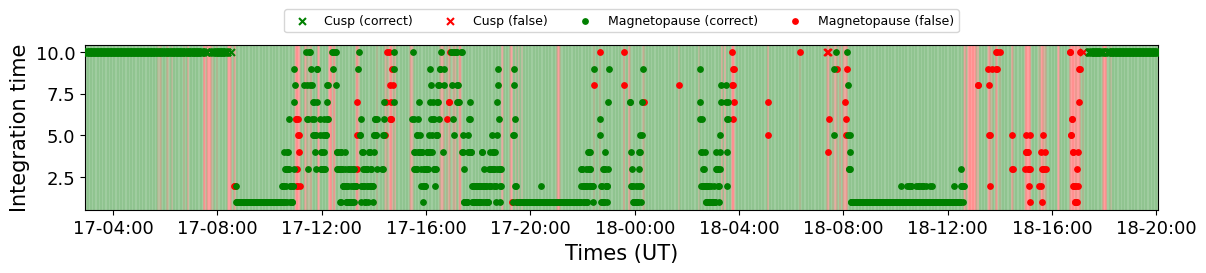

In [11]:
dates = pd.to_datetime(times)
correct = predicted_category == gt_category

fig, ax = plt.subplots(figsize=(12, 3))
[ax.axvline(v, color='g', alpha=0.1) for v in dates[correct]]
[ax.axvline(v, color='r', alpha=0.1) for v in dates[~correct]]

cusp_idx = np.flatnonzero(predicted_category == 'cusp')
mp_idx = np.flatnonzero(predicted_category == 'mp')
cusp_correct = cusp_idx[gt_category[cusp_idx] == 'cusp']
cusp_false = cusp_idx[gt_category[cusp_idx] != 'cusp']
mp_correct = mp_idx[gt_category[mp_idx] == 'mp']
mp_false = mp_idx[gt_category[mp_idx] != 'mp']

ax.scatter(dates[cusp_correct], predicted_ni[cusp_correct], marker='x', color='g', s=25, zorder=1000, label='Cusp (correct)')
ax.scatter(dates[cusp_false], predicted_ni[cusp_false], marker='x', color='r', s=25, zorder=15, label='Cusp (false)')
ax.scatter(dates[mp_correct], predicted_ni[mp_correct], marker='o', color='g', s=15, zorder=1000, label='Magnetopause (correct)')
ax.scatter(dates[mp_false], predicted_ni[mp_false], marker='o', color='r', s=15, zorder=15, label='Magnetopause (false)')

ax.set_ylabel("Integration time", fontsize=15)
ax.set_xlabel("Times (UT)", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_xlim(dates[I_MIN], dates[I_MAX - 1])  # cut to the range where Test 2 had enough neighbouring images
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%H:%M'))
ax.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.25))
fig.tight_layout()
fig.savefig('timeserie_categories_module.pdf')

### Standalone accuracy of Test 2 (cusp identification) on all the images

Test 2 run unconditionally on every image in `[0, N_IMAGES)`, compared
directly against the ground-truth cusp label. `dti.stack_images` clips safely
at the array boundaries (`max(0, ...)` / `min(len(directories), ...)`), so
every image -- including the ones near the very start/end -- uses the largest
window that fits, up to 30 frames.

In [12]:
def test2_accuracy_on(i_values, n_components=K_FIDUCIAL, n_workers=10, ni_cusp=30):
    def _test2(i):
        cusp_image = dti.remove_noise_with_tsvd(dti.stack_images(i, ni_cusp, path_directories), n_components=n_components)
        return dti.test2_is_cusp(cusp_image)

    with Pool(n_workers) as pool:
        predicted = np.array(pool.map(_test2, i_values))

    truth = gt_cusp[i_values]
    accuracy = (predicted == truth).mean() * 100
    tp = int(np.sum(predicted & truth))
    tn = int(np.sum(~predicted & ~truth))
    fp = int(np.sum(predicted & ~truth))
    fn = int(np.sum(~predicted & truth))
    return accuracy, (tp, tn, fp, fn)


all_i = np.arange(N_IMAGES)
test2_all_acc, (test2_all_tp, test2_all_tn, test2_all_fp, test2_all_fn) = test2_accuracy_on(all_i)
test2_all_acc, test2_all_tp, test2_all_tn, test2_all_fp, test2_all_fn

(np.float64(95.39999999999999), 482, 1903, 64, 51)

### Test 3: what does a failed Gaussian fit usually mean?

`test3_is_mp_in_fov` fits an asymmetric Gaussian to the phi-profile and returns
`False` either when the fit converges but lands outside +/-8 deg, or when
`curve_fit` raises `RuntimeError` (no convergence at all). The function itself
doesn't distinguish the two. This reruns the fit for every image (fixed
`ni_mp = 10` window, `n_components = 10`), catching the exception explicitly,
and checks -- for images where the fit failed to converge -- whether the
ground-truth label (`gt_mp_raw`, from the noise-free simulation) says the
subsolar magnetopause was actually present.

In [13]:
def test3_fit_status(i, n_components=K_FIDUCIAL, ni_mp=10):
    """(fit_failed, mp_predicted) for image i, replicating test3_is_mp_in_fov's
    internal try/except so a non-convergent fit can be told apart from a fit
    that simply lands outside +/-8 deg."""
    mp_image = dti.remove_noise_with_tsvd(dti.stack_images(i, ni_mp, path_directories), n_components=n_components)
    av_phi = dti.average_along_phi_axis(mp_image)
    phi = dti.PHI_FOV_DEG if len(av_phi) == len(dti.PHI_FOV_DEG) else np.linspace(-7.75, 7.75, len(av_phi))
    initial_guess = [av_phi.max(), phi[av_phi.argmax()], 3.0, 2.0, av_phi.min()]
    try:
        popt, _ = curve_fit(dti.asymmetric_gaussian, phi, av_phi, p0=initial_guess)
    except RuntimeError:
        return True, False
    return False, bool(abs(popt[1]) <= 8)


def test3_fit_failures(n_components=K_FIDUCIAL, n_workers=10, ni_mp=10):
    i_values = np.arange(N_IMAGES)

    def _run(i):
        return test3_fit_status(i, n_components=n_components, ni_mp=ni_mp)

    with Pool(n_workers) as pool:
        results = pool.map(_run, i_values)

    fit_failed = np.array([r[0] for r in results])
    return i_values[fit_failed]


failed_i = test3_fit_failures()
gt_mp_at_failures = gt_mp_raw[failed_i]
n_failed = len(failed_i)
n_mp_present = int(gt_mp_at_failures.sum())
n_mp_absent = n_failed - n_mp_present
n_failed, n_mp_present, n_mp_absent

(321, 94, 227)

### Trying a more robust Test 3 fit

Two changes, applied only to the 321 images that previously failed to
converge: a data-driven initial guess (half-max crossing on each side of the
peak gives a real width estimate, instead of the fixed 3/2 deg guess -- which
also had the wrong `amplitude` convention: the model's `amplitude` parameter is
the height *above* `min_val`, so the original `p0` of `av_phi.max()` was
already off by `av_phi.min()`), and bounded optimization (`method='trf'`,
positive widths/amplitude, more function evaluations) instead of the
unconstrained default.

If this converts failures into fits that agree with ground truth more often
than not, it's worth adopting; if it just converts them into confidently wrong
fits, it isn't.

In [14]:
def estimate_initial_guess(phi, av_phi):
    amplitude = av_phi.max() - av_phi.min()
    peak_idx = av_phi.argmax()
    mean = phi[peak_idx]
    half_level = av_phi.min() + amplitude / 2
    to_sigma = 1.1774  # HWHM -> Gaussian sigma

    left = phi[:peak_idx + 1][av_phi[:peak_idx + 1] <= half_level]
    sigma_left = max((mean - left[-1]) / to_sigma, 0.5) if len(left) else 3.0

    right = phi[peak_idx:][av_phi[peak_idx:] <= half_level]
    sigma_right = max((right[0] - mean) / to_sigma, 0.5) if len(right) else 2.0

    return [amplitude, mean, sigma_left, sigma_right, av_phi.min()]


def test3_improved_fit(i, n_components=K_FIDUCIAL, ni_mp=10):
    mp_image = dti.remove_noise_with_tsvd(dti.stack_images(i, ni_mp, path_directories), n_components=n_components)
    av_phi = dti.average_along_phi_axis(mp_image)
    phi = dti.PHI_FOV_DEG if len(av_phi) == len(dti.PHI_FOV_DEG) else np.linspace(-7.75, 7.75, len(av_phi))
    p0 = estimate_initial_guess(phi, av_phi)

    bounds = (
        [0, phi.min() - 5, 0.1, 0.1, -np.inf],
        [np.inf, phi.max() + 5, 50, 50, np.inf],
    )
    try:
        popt, _ = curve_fit(dti.asymmetric_gaussian, phi, av_phi, p0=p0, bounds=bounds, method='trf', max_nfev=5000)
    except RuntimeError:
        return False, False
    return True, bool(abs(popt[1]) <= 8)


def evaluate_improved_fit(i_values, n_components=K_FIDUCIAL, n_workers=10, ni_mp=10):
    def _run(i):
        return test3_improved_fit(i, n_components=n_components, ni_mp=ni_mp)

    with Pool(n_workers) as pool:
        results = pool.map(_run, i_values)

    converged = np.array([r[0] for r in results])
    predicted = np.array([r[1] for r in results])
    return converged, predicted


converged, predicted = evaluate_improved_fit(failed_i)
truth = gt_mp_raw[failed_i]

n_converged = int(converged.sum())
correct_among_converged = int((predicted[converged] == truth[converged]).sum())
still_failed = int((~converged).sum())

n_converged, correct_among_converged, still_failed

(318, 161, 3)

## Precision / recall / accuracy vs. number of components

In [15]:
ratio = (dff.pic_im / dff.std_phi_noise).values

precision, recall, accuracy = [], [], []
for k in dico.keys():
    tp_k, tn_k, fp_k, fn_k = classify(dico[k].it, valid_msh, ratio=ratio)
    precision.append(len(tp_k) / (len(tp_k) + len(fp_k)) * 100)
    recall.append(len(tp_k) / (len(tp_k) + len(fn_k)) * 100)
    accuracy.append((len(tp_k) + len(tn_k)) / N_IMAGES * 100)

precision, recall, accuracy = np.array(precision), np.array(recall), np.array(accuracy)
best_k = np.array(list(dico.keys()))[accuracy.argmax()]
best_k, accuracy.max()

(np.int64(10), np.float64(90.96))

### Figure — accuracy / precision / recall vs. component count (`stat_DIT_module.pdf`)

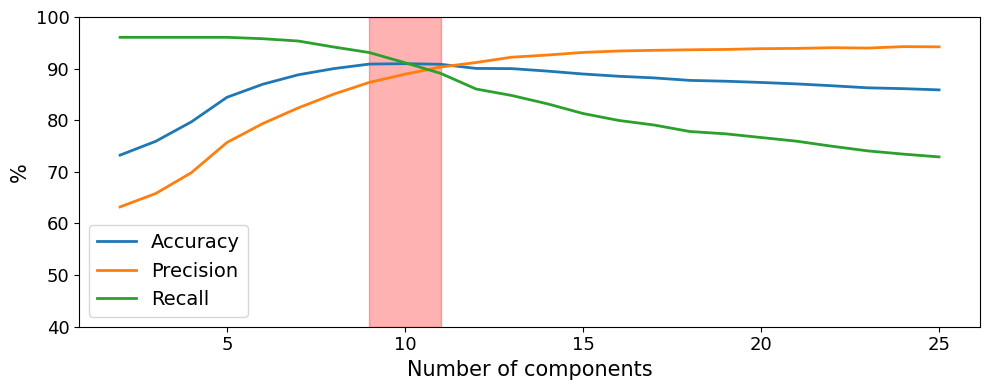

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(dico.keys(), accuracy, label='Accuracy', lw=2)
plt.plot(dico.keys(), precision, label='Precision', lw=2)
plt.plot(dico.keys(), recall, label='Recall', lw=2)
plt.axvspan(9, 11, color='r', alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=13)
plt.legend(fontsize=14)
plt.xlabel('Number of components', fontsize=15)
plt.ylabel('%', fontsize=15)
plt.ylim(40, 100)
plt.tight_layout()
plt.savefig('stat_DIT_module.pdf')

## Example reconstructions: DIT output (module) vs. ground truth

In [17]:
def reconstruct_pair(i, ni, k):
    noisy = dti.remove_noise_with_tsvd(dti.stack_images(i, ni, path_directories), n_components=k)
    image, _bkg = reconstruct_ground_truth(i, ni)
    return noisy, image


def integration_time_or(i, k, fallback):
    ni = dico[k].it.iloc[i]
    return fallback if np.isnan(ni) else ni

### Figure — `test1_module.pdf` (msh events, i = 1850, 1507, 1630)

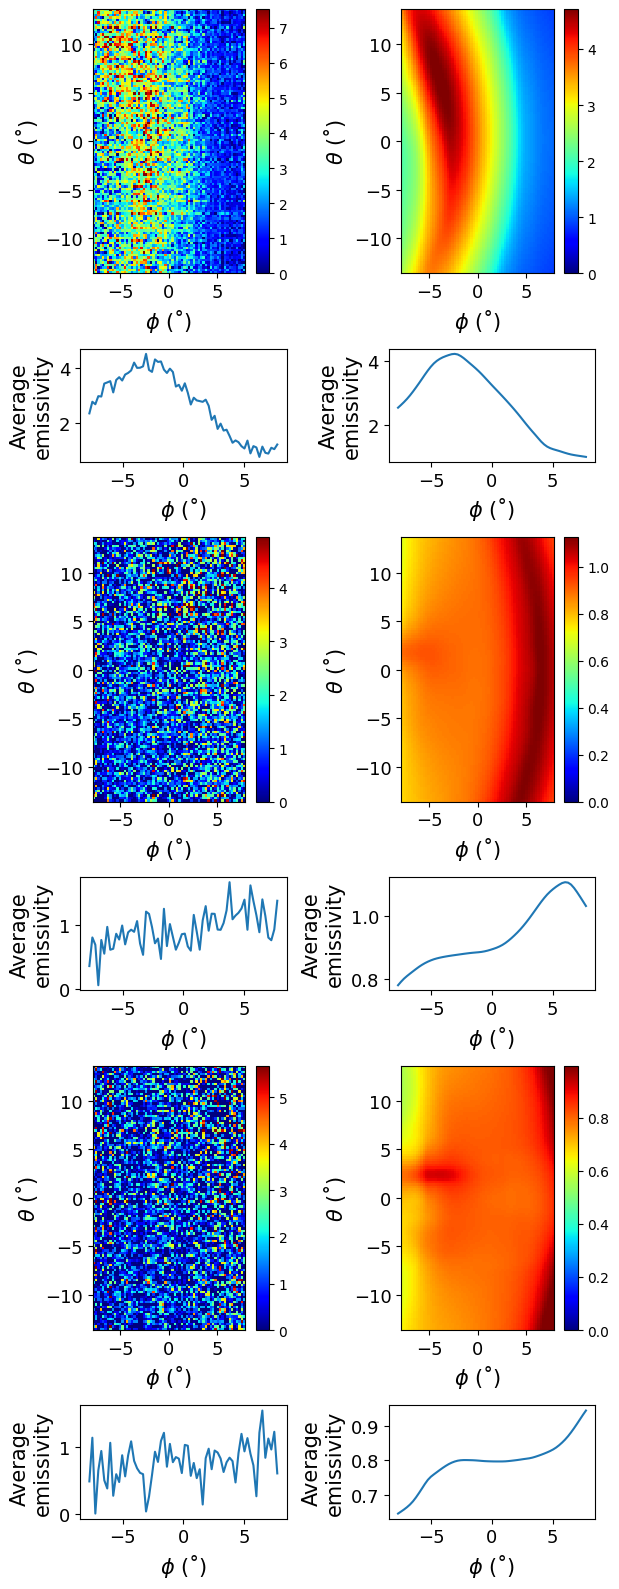

In [18]:
fig, axs = plt.subplots(6, 3, figsize=(8, 16), width_ratios=(5, 5, 2), height_ratios=(7, 3, 7, 3, 7, 3))
k = K_FIDUCIAL
for row, i in zip((0, 2, 4), (1850, 1507, 1630)):
    ni = integration_time_or(i, k, fallback=10)
    noisy, image = reconstruct_pair(i, ni, k)

    c = axs[row, 0].pcolormesh(PP, TT, noisy, cmap='jet', norm=Normalize(0, np.quantile(noisy, 0.99)))
    fig.colorbar(c, ax=axs[row, 0])
    c = axs[row, 1].pcolormesh(PP, TT, image, cmap='jet', norm=Normalize(0, np.quantile(image, 0.99)))
    fig.colorbar(c, ax=axs[row, 1])
    axs[row, 0].set_aspect('equal')
    axs[row, 1].set_aspect('equal')
    axs[row + 1, 0].plot(P, np.mean(noisy, axis=0))
    axs[row + 1, 1].plot(P, np.mean(image, axis=0))

for ax in axs.ravel():
    ax.set_xlabel(r'$\phi$ (˚)', fontsize=15)
    ax.set_ylabel(r'$\theta$ (˚)', fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=13)
for row in (1, 3, 5):
    axs[row, 0].set_ylabel('Average\nemissivity', fontsize=15, multialignment='center')
    axs[row, 1].set_ylabel('Average\nemissivity', fontsize=15, multialignment='center')
for ax in axs[:, -1]:
    ax.remove()
fig.tight_layout()
fig.savefig('test1_module.pdf')

### Figure — `test3_module.pdf` (msh events, i = 800, 2200, with magnetopause fit)

i=800: fitted mp crossing at phi=2.21 deg
i=2200: fitted mp crossing at phi=11.69 deg


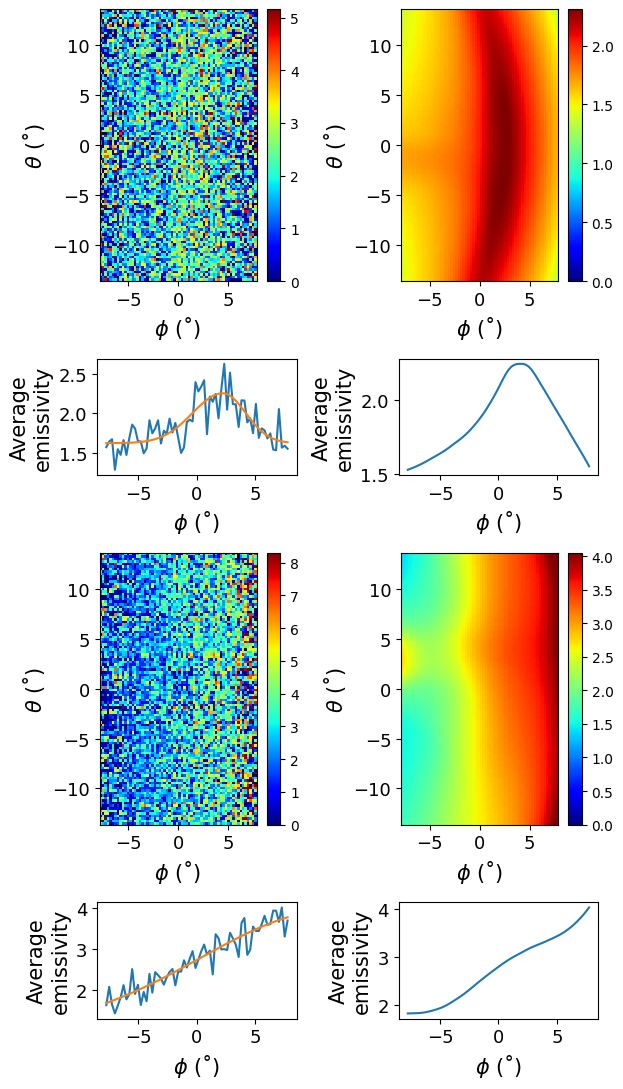

In [19]:
fig, axs = plt.subplots(4, 3, figsize=(8, 11), width_ratios=(5, 5, 2), height_ratios=(7, 3, 7, 3))
k = K_FIDUCIAL
fallback_ni = {800: 10, 2200: 5}
for row, i in zip((0, 2), (800, 2200)):
    ni = integration_time_or(i, k, fallback=fallback_ni[i])
    noisy, image = reconstruct_pair(i, ni, k)

    c = axs[row, 0].pcolormesh(PP, TT, noisy, cmap='jet', norm=Normalize(0, np.quantile(noisy, 0.99)))
    fig.colorbar(c, ax=axs[row, 0])
    c = axs[row, 1].pcolormesh(PP, TT, image, cmap='jet', norm=Normalize(0, np.quantile(image, 0.99)))
    fig.colorbar(c, ax=axs[row, 1])
    axs[row, 0].set_aspect('equal')
    axs[row, 1].set_aspect('equal')

    av_phi_image = np.mean(image, axis=0)
    av_phi_noisy = np.mean(noisy, axis=0)
    axs[row + 1, 1].plot(P, av_phi_image)
    axs[row + 1, 0].plot(P, av_phi_noisy)

    popt, _ = curve_fit(
        dti.asymmetric_gaussian, P, av_phi_noisy,
        p0=[av_phi_noisy.max(), P[av_phi_noisy.argmax()], 3, 2, av_phi_noisy.min()],
    )
    axs[row + 1, 0].plot(P, dti.asymmetric_gaussian(P, *popt))
    print(f'i={i}: fitted mp crossing at phi={popt[1]:.2f} deg')

for ax in axs.ravel():
    ax.set_xlabel(r'$\phi$ (˚)', fontsize=15)
    ax.set_ylabel(r'$\theta$ (˚)', fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=13)
for row in (1, 3):
    axs[row, 0].set_ylabel('Average\nemissivity', fontsize=15, multialignment='center')
    axs[row, 1].set_ylabel('Average\nemissivity', fontsize=15, multialignment='center')
for ax in axs[:, -1]:
    ax.remove()
fig.tight_layout()
fig.savefig('test3_module.pdf')